In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Placement (1).csv')

In [3]:
df=df.iloc[:,1:]

In [4]:
df.sample(5)

,CGPA,IQ,Placement
39,4.6,146,0
6,5.7,143,0
78,6.1,81,0
15,5.1,176,0
38,6.5,160,1


# Train Test Split

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop('Placement',axis=1),
                                               df['Placement'],test_size=0.2,
                                               random_state=0)

In [6]:
X_train.shape,X_test.shape

((80, 2), (20, 2))

# StandardScaler

In [7]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

# fit the scaler to the train set, it will learn the parameters(mean and S.D)
scaler.fit(X_train)

# transforms train and test sets
X_train_scaled= scaler.transform(X_train)
X_test_scaled= scaler.transform(X_test)
# scaler.transform(X_train) returns a plain NumPy array, not a DataFrame

In [8]:
X_train_scaled= pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled= pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [9]:
np.round(X_train.describe(),1)

,CGPA,IQ
count,80.0,80.0
mean,6.0,121.0
std,1.1,38.9
min,3.3,37.0
25%,5.1,94.8
50%,6.0,127.5
75%,6.9,143.8
max,8.5,233.0


In [10]:
np.round(X_train_scaled.describe(),1)

,CGPA,IQ
count,80.0,80.0
mean,-0.0,-0.0
std,1.0,1.0
min,-2.4,-2.2
25%,-0.8,-0.7
50%,0.0,0.2
75%,0.8,0.6
max,2.2,2.9


# Effect of Scaling

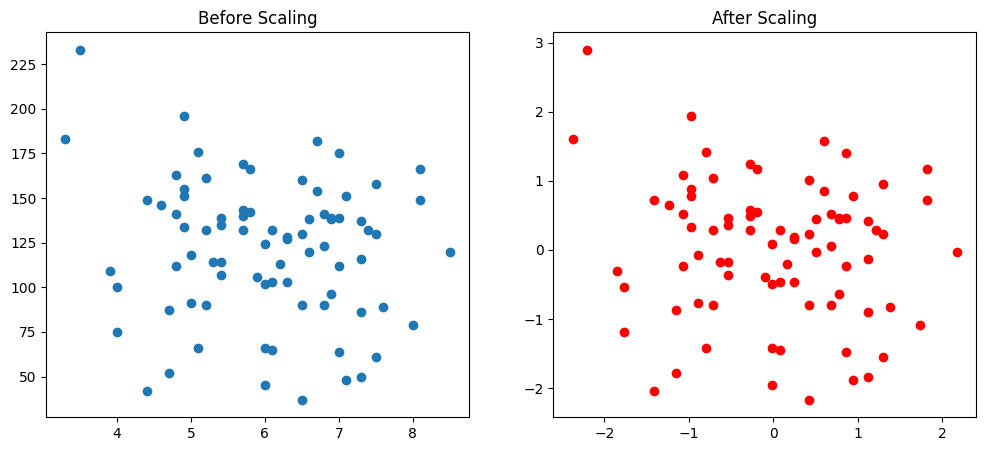

In [11]:
fig,(ax1,ax2) =plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(X_train['CGPA'],X_train['IQ'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['CGPA'],X_train_scaled['IQ'],color='red')
ax2.set_title("After Scaling")
plt.show()

# Creates a figure with 2 subplots side by side (ncols=2).
# ax1 and ax2 are the two individual plot areas.

<Axes: title={'center': 'After Scaling'}, xlabel='CGPA', ylabel='Density'>

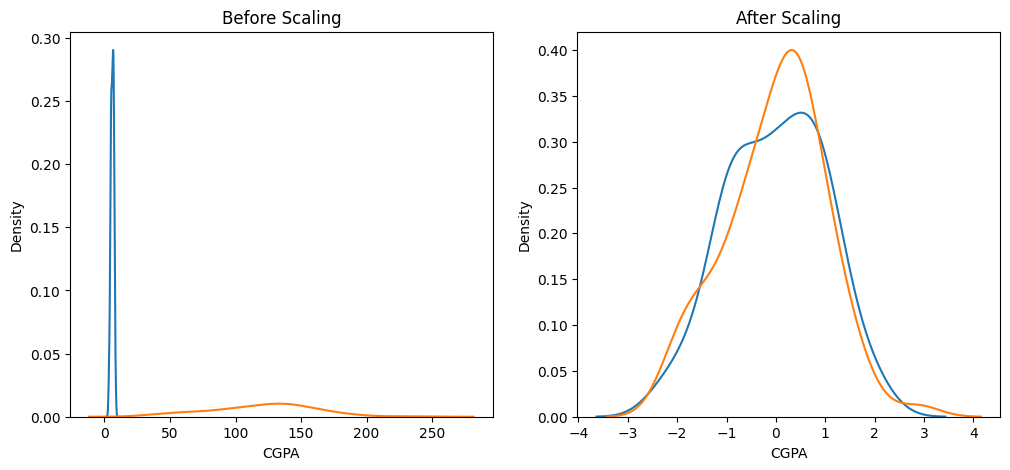

In [12]:
fig,(ax1,ax2) =plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train['CGPA'],ax=ax1)
sns.kdeplot(X_train['IQ'],ax=ax1)

# after scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled['CGPA'],ax=ax2)
sns.kdeplot(X_train_scaled['IQ'],ax=ax2)

# kdeplot(Kernel Density Curve): draws a probability density curve

# Applying Algorithm and Checking Scaling's Impact

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
lr=LogisticRegression(random_state=0)
lr_scaled=LogisticRegression(random_state=0)

In [15]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
y_pred=lr.predict(X_test)
y_pred_scaled=lr_scaled.predict(X_test_scaled)

In [17]:
from sklearn.metrics import accuracy_score

In [18]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.85
Scaled 0.85
